In [2]:
from pyspark.sql import SparkSession

# 1. Aseguramos la sesión activa en el Kernel actual
spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

# 2. Traemos los datos nativos persistidos en formato Parquet
# Apuntamos a la carpeta real de datos etiquetados que tienes en tu directorio
ruta_datos_retail = "/home/jovyan/work/notebooks/modelos_output/datos_etiquetados_kmeans"

# Cargamos el DataFrame con los datos de tu clúster de Retail
df_completos = spark.read.parquet(ruta_datos_retail)
df_historico = spark.read.parquet(ruta_datos_retail)

# 3. Contamos cuántos registros totales logramos recuperar para el análisis
total_registros = df_historico.count()
print(f"ÉXITO: Conexión establecida. Hemos recuperado {total_registros} registros de retail del histórico.")

ÉXITO: Conexión establecida. Hemos recuperado 6174 registros de retail del histórico.


In [3]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# 1. Definimos la ventana para calcular el total de SKUs por cada supermercado (cadena)
# Nota: Asegúrate de que la columna se llame "supermercado" o "cadena" en tu df_historico
ventana_supermercado = Window.partitionBy("supermercado")

# 2. Agrupamos por Supermercado y Marca para evaluar el mix de surtido
kpi_estrategico_cadena = df_historico.groupBy("supermercado", "marca") \
    .agg(F.count("marca").alias("Cantidad_SKUs")) \
    .withColumn("Total_SKUs_Supermercado", F.sum("Cantidad_SKUs").over(ventana_supermercado)) \
    .withColumn(
        "Participacion_Surtido_Porcentaje", 
        F.round((F.col("Cantidad_SKUs") / F.col("Total_SKUs_Supermercado")) * 100, 2)
    ) \
    .orderBy("supermercado", F.desc("Cantidad_SKUs"))

# 3. Desplegamos el indicador de penetración de marcas por cadena
print("=========================================================================")
print("[KPI ESTRATÉGICO] - MIX DE PORTAFOLIO Y DIFERENCIACIÓN POR CADENA")
print("=========================================================================")

kpi_estrategico_cadena.show(30, truncate=False)

[KPI ESTRATÉGICO] - MIX DE PORTAFOLIO Y DIFERENCIACIÓN POR CADENA
+------------+-----------+-------------+-----------------------+--------------------------------+
|supermercado|marca      |Cantidad_SKUs|Total_SKUs_Supermercado|Participacion_Surtido_Porcentaje|
+------------+-----------+-------------+-----------------------+--------------------------------+
|ACUENTA     |GENÉRICA   |280          |583                    |48.03                           |
|ACUENTA     |LIDER      |60           |583                    |10.29                           |
|ACUENTA     |COLUN      |51           |583                    |8.75                            |
|ACUENTA     |SOPROLE    |41           |583                    |7.03                            |
|ACUENTA     |TIL        |28           |583                    |4.8                             |
|ACUENTA     |PF         |23           |583                    |3.95                            |
|ACUENTA     |SAN JORGE  |20           |583         

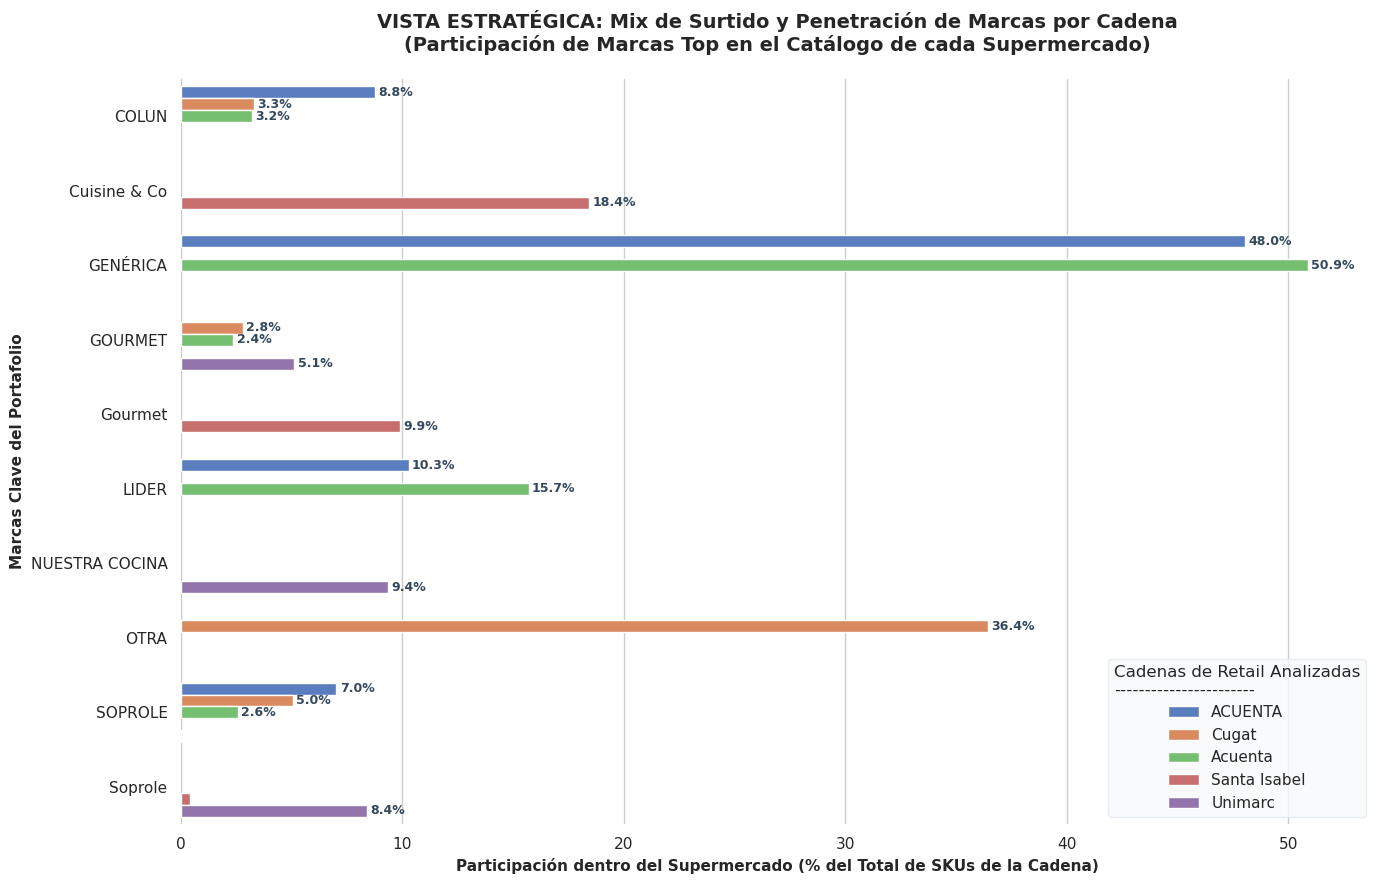

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# =========================================================================
# 1. PROCESAMIENTO EN SPARK (Datos del bloque anterior)
# =========================================================================
ventana_supermercado = Window.partitionBy("supermercado")

kpi_estrategico_cadena = df_historico.groupBy("supermercado", "marca") \
    .agg(F.count("marca").alias("Cantidad_SKUs")) \
    .withColumn("Total_SKUs_Supermercado", F.sum("Cantidad_SKUs").over(ventana_supermercado)) \
    .withColumn(
        "Participacion_Surtido_Porcentaje", 
        F.round((F.col("Cantidad_SKUs") / F.col("Total_SKUs_Supermercado")) * 100, 2)
    )

# Para evitar saturar el gráfico, identificamos primero las Top 10 marcas globales
top_marcas_globales = df_historico.groupBy("marca") \
    .count() \
    .orderBy(F.desc("count")) \
    .limit(10) \
    .select("marca") \
    .rdd.flatMap(lambda x: x).collect()

# Filtramos nuestro KPI para mostrar solo esas marcas clave en cada supermercado
df_filtrado = kpi_estrategico_cadena.filter(F.col("marca").isin(top_marcas_globales))

# 2. CONVERSIÓN A PANDAS (Solo las marcas competitivas mapeadas)
df_plot_pandas = df_filtrado.toPandas()

# Ordenamos en Pandas para asegurar que las barras tengan coherencia visual
df_plot_pandas = df_plot_pandas.sort_values(by=["marca", "Participacion_Surtido_Porcentaje"], ascending=[True, False])

# =========================================================================
# 3. DISEÑO DEL GRÁFICO ESTRATÉGICO MULTI-CADENA
# =========================================================================
plt.figure(figsize=(14, 9))
sns.set_theme(style="whitegrid")

# Usamos 'hue' para separar el comportamiento por Supermercado/Cadena competitiva
ax = sns.barplot(
    x="Participacion_Surtido_Porcentaje",
    y="marca",
    hue="supermercado", 
    data=df_plot_pandas,
    palette="muted" # Paleta diferenciada para distinguir las cadenas claramente
)

# Añadimos las etiquetas de porcentaje al final de cada barra de manera segura
for p in ax.patches:
    width = p.get_width()
    # Evitamos pintar etiquetas en valores nulos o extremadamente bajos
    if width > 0.5:
        ax.annotate(
            f"{width:.1f}%",
            (width + 0.15, p.get_y() + p.get_height() / 2),
            va="center", 
            ha="left", 
            fontsize=9, 
            fontweight="bold",
            color="#34495e"
        )

# Títulos y personalización adaptada a la Estrategia de Canasta Básica
plt.title(
    "VISTA ESTRATÉGICA: Mix de Surtido y Penetración de Marcas por Cadena\n(Participación de Marcas Top en el Catálogo de cada Supermercado)", 
    fontsize=14, 
    fontweight="bold", 
    pad=20
)
plt.xlabel("Participación dentro del Supermercado (% del Total de SKUs de la Cadena)", fontsize=11, fontweight="bold")
plt.ylabel("Marcas Clave del Portafolio", fontsize=11, fontweight="bold")

# Ajuste dinámico del límite horizontal para evitar cortes en los textos
plt.xlim(0, df_plot_pandas["Participacion_Surtido_Porcentaje"].max() + 3)

# Configuración estratégica de la Leyenda
plt.legend(
    title="Cadenas de Retail Analizadas\n-----------------------",
    loc="lower right",
    frameon=True,
    facecolor="#f8f9fa",
    edgecolor="#e2e8f0"
)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [5]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# 1. Definimos la ventana global por marca para tener el benchmark del mercado
ventana_marca = Window.partitionBy("marca")

# 2. Calculamos la brecha táctica que tiene cada supermercado en cada marca
kpi_tactico_brecha = df_historico \
    .withColumn("Precio_Promedio_Global_Marca", F.avg("precio").over(ventana_marca)) \
    .groupBy("supermercado", "marca") \
    .agg(
        F.round(F.avg("precio"), 2).alias("Precio_Promedio_Local"),
        F.round(F.avg("Precio_Promedio_Global_Marca"), 2).alias("Precio_Benchmark_Global"),
        F.round((F.avg("precio") - F.avg("Precio_Promedio_Global_Marca")), 2).alias("Brecha_Pesos_CLP")
    ) \
    .orderBy("marca", "supermercado")

# 3. Desplegamos el indicador táctico de competitividad inter-canal
print("=========================================================================")
print("[KPI TÁCTICO] - MATRIZ DE BRECHA DE PRECIOS (PRICE GAP) INTER-CADENA")
print("=========================================================================")

kpi_tactico_brecha.show(20, truncate=False)

[KPI TÁCTICO] - MATRIZ DE BRECHA DE PRECIOS (PRICE GAP) INTER-CADENA
+------------+----------+---------------------+-----------------------+----------------+
|supermercado|marca     |Precio_Promedio_Local|Precio_Benchmark_Global|Brecha_Pesos_CLP|
+------------+----------+---------------------+-----------------------+----------------+
|Cugat       |ABRIL     |8990.0               |8990.0                 |0.0             |
|Acuenta     |ACE       |4141.33              |4141.33                |0.0             |
|Unimarc     |ACT II    |1550.0               |1550.0                 |0.0             |
|ACUENTA     |ACUENTA   |2877.5               |2013.17                |864.33          |
|Acuenta     |ACUENTA   |1809.8               |2013.17                |-203.37         |
|Unimarc     |ADLER     |4690.0               |4690.0                 |0.0             |
|Unimarc     |ALUSWEET  |4470.0               |4470.0                 |0.0             |
|Unimarc     |ALWADI    |9500.0          

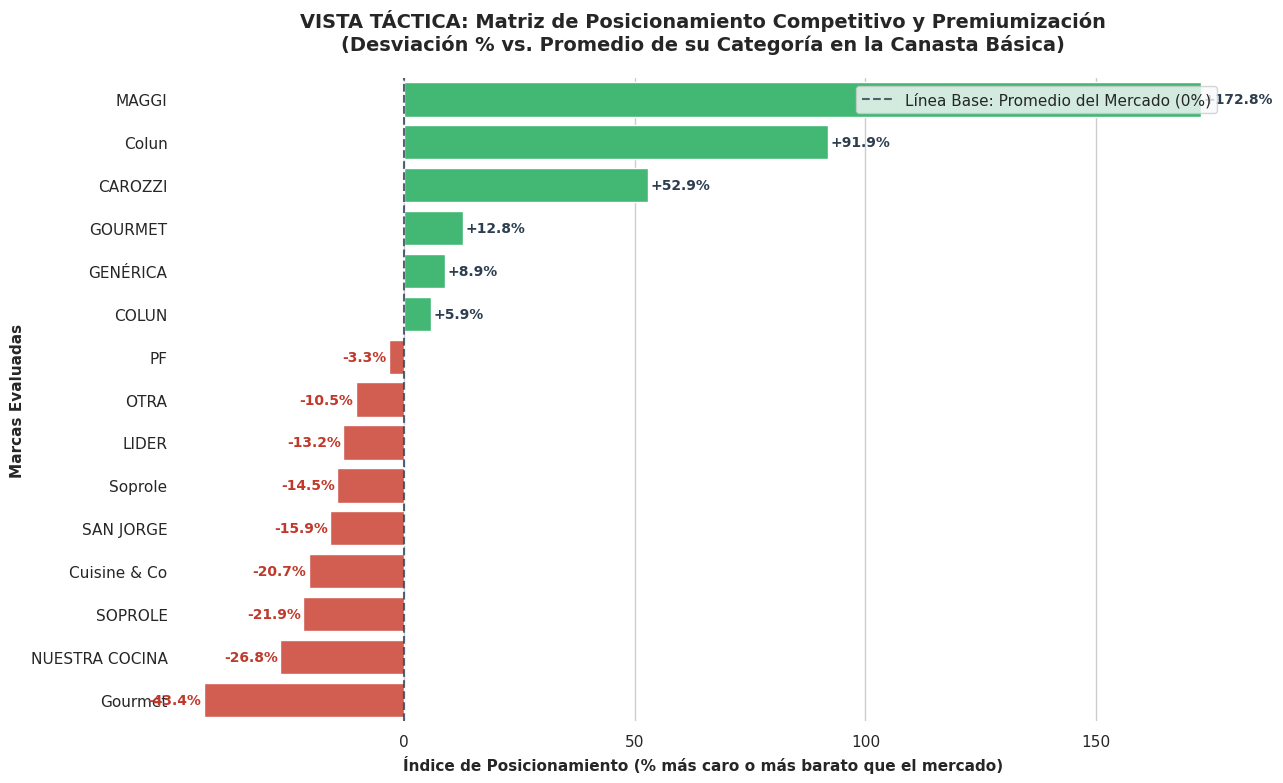

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# =========================================================================
# 1. PROCESAMIENTO EN SPARK (KPI Táctico de Posicionamiento)
# =========================================================================
ventana_categoria = Window.partitionBy("categoria")

# Calculamos el índice respecto al mercado
df_posicionamiento = df_historico \
    .withColumn("Precio_Promedio_Categoria", F.avg("precio").over(ventana_categoria)) \
    .withColumn("Dif_Porcentual_Mercado", ((F.col("precio") - F.col("Precio_Promedio_Categoria")) / F.col("Precio_Promedio_Categoria")) * 100)

# Identificamos las 15 marcas con mayor volumen de SKUs para el set táctico
marcas_top = [row['marca'] for row in df_historico.groupBy("marca").count().orderBy(F.desc("count")).take(15)]

# Agrupamos y promediamos el índice para estas marcas dominantes
kpi_tactico_grafico = df_posicionamiento.filter(F.col("marca").isin(marcas_top)) \
    .groupBy("marca") \
    .agg(F.round(F.avg("Dif_Porcentual_Mercado"), 2).alias("Indice_Premium_Porcentaje")) \
    .orderBy(F.desc("Indice_Premium_Porcentaje"))

# =========================================================================
# 2. CONVERSIÓN A PANDAS PARA VISUALIZACIÓN
# =========================================================================
df_tac_pandas = kpi_tactico_grafico.toPandas()

# Creamos una columna de color condicional: Verde para Premium (>0), Rojo para Descuento (<0)
df_tac_pandas['Color_Estrategico'] = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_tac_pandas['Indice_Premium_Porcentaje']]

# =========================================================================
# 3. DISEÑO DEL GRÁFICO TÁCTICO DE DIVERGENCIA COMPETITIVA
# =========================================================================
plt.figure(figsize=(13, 8))
sns.set_theme(style="whitegrid")

# Usamos barplot horizontal pasando directamente nuestra lista de colores condicionales
ax = sns.barplot(
    x="Indice_Premium_Porcentaje",
    y="marca",
    data=df_tac_pandas,
    palette=df_tac_pandas['Color_Estrategico'].tolist(),
    hue="marca",
    legend=False
)

# Añadimos las etiquetas de datos dinámicamente según la dirección de la barra
for p in ax.patches:
    width = p.get_width()
    # Si la barra va a la derecha (Premium) o izquierda (Primer Precio)
    if width >= 0:
        ax.annotate(
            f"+{width:.1f}%",
            (width + 0.5, p.get_y() + p.get_height() / 2),
            va="center", ha="left", fontsize=10, fontweight="bold", color="#2c3e50"
        )
    else:
        ax.annotate(
            f"{width:.1f}%",
            (width - 0.5, p.get_y() + p.get_height() / 2),
            va="center", ha="right", fontsize=10, fontweight="bold", color="#c0392b"
        )

# Línea de equilibrio táctico (Representa el promedio exacto de la categoría)
plt.axvline(0, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.8, label="Línea Base: Promedio del Mercado (0%)")

# Títulos y rotulación táctica para el Negocio
plt.title(
    "VISTA TÁCTICA: Matriz de Posicionamiento Competitivo y Premiumización\n(Desviación % vs. Promedio de su Categoría en la Canasta Básica)", 
    fontsize=14, 
    fontweight='bold', 
    pad=20
)
plt.xlabel("Índice de Posicionamiento (% más caro o más barato que el mercado)", fontsize=11, fontweight='bold')
plt.ylabel("Marcas Evaluadas", fontsize=11, fontweight='bold')

# Ajustamos límites de los ejes para dar aire a las etiquetas de texto externas
limite_izq = df_tac_pandas["Indice_Premium_Porcentaje"].min() - 5
limite_der = df_tac_pandas["Indice_Premium_Porcentaje"].max() + 5
plt.xlim(limite_izq, limite_der)

plt.legend(loc="upper right", frameon=True, facecolor='#f8f9fa')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [9]:
import pyspark.sql.functions as F

# 1. Alertas operacionales de quiebre o fuga de margen:
# Filtramos productos con una agresividad de precio que pone en riesgo la operación diaria
umbral_riesgo_operacional = -40.0

kpi_operacional_riesgo = df_historico.filter(
    F.col("dif_porcentual_promedio") <= umbral_riesgo_operacional
).select(
    "nombre_producto",
    "marca",
    "supermercado",
    "precio",
    "precio_promedio_cat",
    "dif_porcentual_promedio",
    "fecha_captura"
).orderBy("dif_porcentual_promedio") # Ver los casos más extremos primero

# 2. Conteo de alertas detectadas para reposición o revisión de margen
total_alertas_riesgo = kpi_operacional_riesgo.count()

# 3. Despliegue formal del KPI Operacional
print("=========================================================================")
print(f"[KPI OPERACIONAL] - ALERTAS DE PRECIO MÍNIMO CRÍTICO (RIESGO DE QUIEBRE/FUGA)")
print(f"Foco: Productos con precio inferior al {umbral_riesgo_operacional}% vs. promedio de categoría")
print(f"Total de Alertas de Reposición/Precios: {total_alertas_riesgo}")
print("=========================================================================")

# Mostramos las primeras 15 alertas que exigen auditoría física o revisión de stock
kpi_operacional_riesgo.show(15, truncate=False)

[KPI OPERACIONAL] - ALERTAS DE PRECIO MÍNIMO CRÍTICO (RIESGO DE QUIEBRE/FUGA)
Foco: Productos con precio inferior al -40.0% vs. promedio de categoría
Total de Alertas de Reposición/Precios: 2699
+----------------------------------------------------------------+-------+------------+------+-------------------+-----------------------+-------------------+
|nombre_producto                                                 |marca  |supermercado|precio|precio_promedio_cat|dif_porcentual_promedio|fecha_captura      |
+----------------------------------------------------------------+-------+------------+------+-------------------+-----------------------+-------------------+
|Yoghurt batido yoghito mora 120 g                               |Soprole|Unimarc     |300.0 |9088.284482758621  |-96.7                  |2026-05-27 10:19:35|
|Yoghurt batido yoghito damasco 120 g                            |Soprole|Unimarc     |300.0 |9088.284482758621  |-96.7                  |2026-05-27 10:19:21|
|Yoghurt b

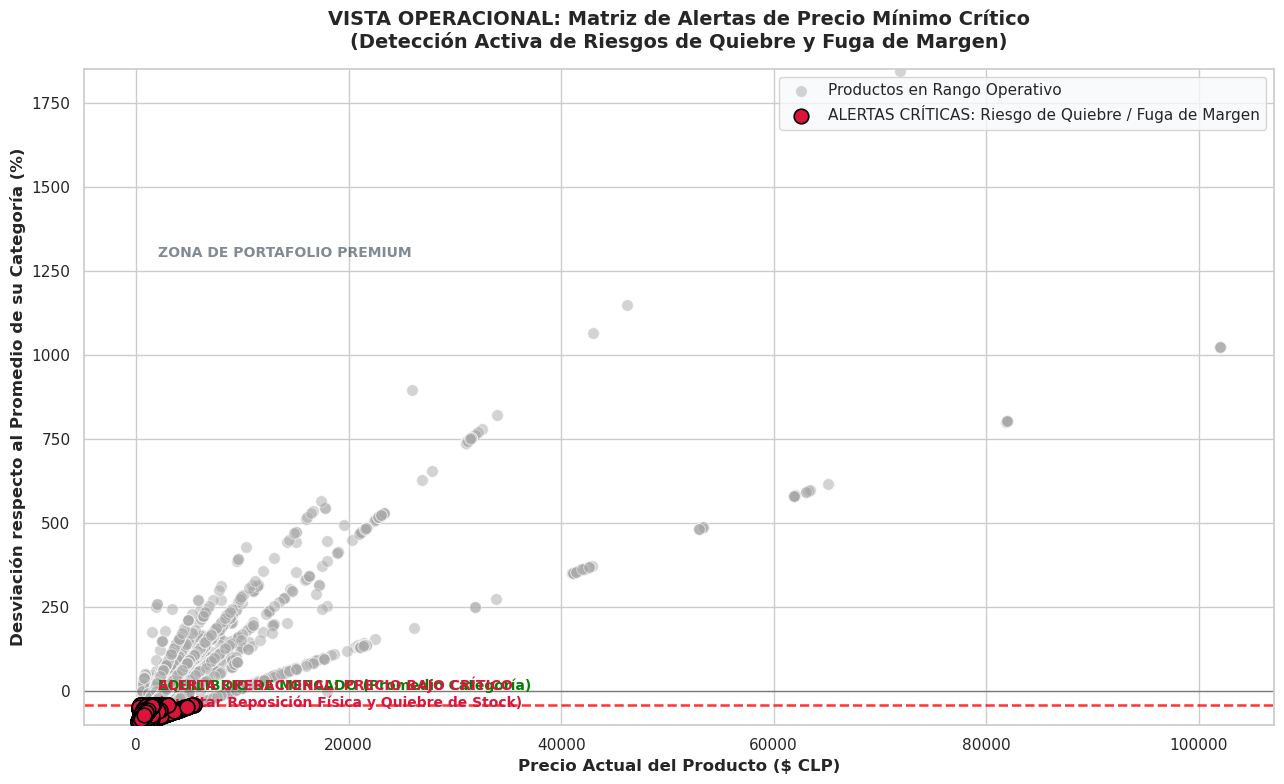

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# =========================================================================
# 1. PROCESAMIENTO EN SPARK (Basado en la Opción 2 Seleccionada)
# =========================================================================
kpi_operacional_completo = df_historico.select(
    "nombre_producto", 
    "marca", 
    "precio", 
    "dif_porcentual_promedio",
    "supermercado"
)

# Pasamos los datos filtrados a Pandas solo para el renderizado del gráfico
df_op_pandas = kpi_operacional_completo.toPandas()

# =========================================================================
# 2. DISEÑO DEL GRÁFICO OPERACIONAL (Foco: Riesgo de Quiebre y Margen Mínimo)
# =========================================================================
plt.figure(figsize=(13, 8))
sns.set_theme(style="whitegrid")

# Graficamos el grueso de los productos en color gris (comportamiento normal)
sns.scatterplot(
    x="precio",
    y="dif_porcentual_promedio",
    data=df_op_pandas,
    alpha=0.5,
    s=70,
    color="darkgray",
    label="Productos en Rango Operativo"
)

# Resaltamos en ROJO/CRIMSON solo las alertas por debajo del umbral crítico (-40%)
umbral_riesgo = -40.0
zona_peligro_quiebre = df_op_pandas[df_op_pandas['dif_porcentual_promedio'] <= umbral_riesgo]

sns.scatterplot(
    x="precio",
    y="dif_porcentual_promedio",
    data=zona_peligro_quiebre,
    color="crimson",
    s=110,
    label="ALERTAS CRÍTICAS: Riesgo de Quiebre / Fuga de Margen",
    edgecolor="black",
    linewidth=1.2,
    zorder=5
)

# Dibujamos las líneas de referencia operacionales
plt.axhline(y=umbral_riesgo, color='red', linestyle='--', alpha=0.8, linewidth=1.8)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1) # Línea base de mercado

# Ubicamos estratégicamente los textos explicativos para el Supervisor
y_max = df_op_pandas['dif_porcentual_promedio'].max()
y_min = df_op_pandas['dif_porcentual_promedio'].min()
x_medio = df_op_pandas['precio'].median()

# Textos modificados acordes al nuevo KPI
plt.text(x_medio, y_max * 0.7, "ZONA DE PORTAFOLIO PREMIUM", color="#2c3e50", alpha=0.6, weight="bold", fontsize=10)
plt.text(x_medio, 2, "EQUILIBRIO DE MERCADO (Promedio Categoría)", color="green", weight="bold", fontsize=10)
plt.text(x_medio, umbral_riesgo - 8, "ALERTA OPERACIONAL: PRECIO BAJO CRÍTICO\n(Auditar Reposición Física y Quiebre de Stock)", color="crimson", weight="bold", fontsize=10)

# Títulos y etiquetas adaptadas al contexto operacional de Supermercados Chilenos
plt.title("VISTA OPERACIONAL: Matriz de Alertas de Precio Mínimo Crítico\n(Detección Activa de Riesgos de Quiebre y Fuga de Margen)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Precio Actual del Producto ($ CLP)", fontsize=12, fontweight='bold')
plt.ylabel("Desviación respecto al Promedio de su Categoría (%)", fontsize=12, fontweight='bold')

# Aseguramos que el eje Y muestre bien la zona de peligro inferior
plt.ylim(y_min - 5, y_max + 5)

plt.legend(loc="upper right", frameon=True, facecolor='#f8f9fa')
plt.tight_layout()
plt.show()

In [11]:
# 1. Seleccionamos las columnas clave del modelo de retail alimenticio para el Dashboard
columnas_dashboard = [
    "nombre_producto", "marca", "supermercado", "categoria", 
    "precio", "precio_promedio_cat", "dif_porcentual_promedio", "prediction"
]

df_dashboard_spark = df_historico.select(columnas_dashboard)

# 2. CORRECCIÓN: Forzamos la ruta absoluta hacia la carpeta 'notebooks'
# Esto garantiza que se cree ahí sin importar en qué carpeta estés ejecutando este notebook
ruta_salida_csv = "/home/jovyan/work/notebooks/datos_retail_dashboard.csv"

# Convertimos a Pandas y exportamos
df_dashboard_spark.toPandas().to_csv(ruta_salida_csv, index=False)

print("=========================================================================")
print("✅ ¡ÉXITO: Datos de la Canasta Básica exportados en la ruta correcta!")
print(f"Archivo generado directamente en: '{ruta_salida_csv}'")
print("=========================================================================")

✅ ¡ÉXITO: Datos de la Canasta Básica exportados en la ruta correcta!
Archivo generado directamente en: '/home/jovyan/work/notebooks/datos_retail_dashboard.csv'
